In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('non_convex_data_1000.csv')

In [14]:
df.head()

,x,f(x)
0,0.479155,0.472010
1,-1.021461,37.567432
2,-4.467154,1507.309054
3,1.130598,5.036163
4,-1.007833,36.566910


In [15]:
import seaborn as sns

<Axes: xlabel='x', ylabel='f(x)'>

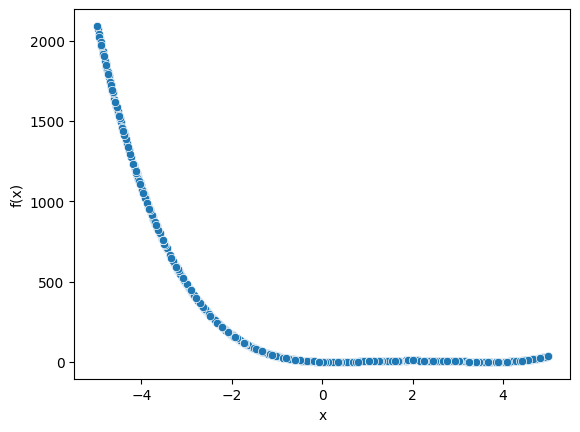

In [16]:
sns.scatterplot(x='x',y='f(x)',data=df)

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df['x'],df['f(x)'],test_size=.2,random_state=42)

In [19]:
from sklearn.preprocessing import PolynomialFeatures

In [21]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(pd.DataFrame(X_train))
X_test_poly = poly.transform(pd.DataFrame(X_test))

In [23]:
X_train_poly

array([[ 1.        , -1.8099215 ,  3.27581584],
       [ 1.        , -1.3502744 ,  1.82324096],
       [ 1.        ,  4.20495646, 17.68165887],
       ...,
       [ 1.        , -4.67042039, 21.81282665],
       [ 1.        , -0.27240118,  0.0742024 ],
       [ 1.        , -1.63226018,  2.66427329]], shape=(800, 3))

In [26]:
X_test_poly[:5]

array([[ 1.        ,  4.53091752, 20.52921355],
       [ 1.        , -3.50893395, 12.31261748],
       [ 1.        ,  4.59249664, 21.09102539],
       [ 1.        ,  3.06956694,  9.42224119],
       [ 1.        ,  0.73039576,  0.53347797]])

In [27]:
poly.fit(X_train_poly,y_train)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
regression_poly = LinearRegression()


In [30]:
regression_poly.fit(X_train_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [31]:
regression_poly.coef_

array([   0.        , -125.83804778,   38.85710275])

In [32]:
regression_poly.intercept_

np.float64(-50.888459751448124)

In [34]:
y_pred = regression_poly.predict(X_test_poly)

<Axes: xlabel='f(x)'>

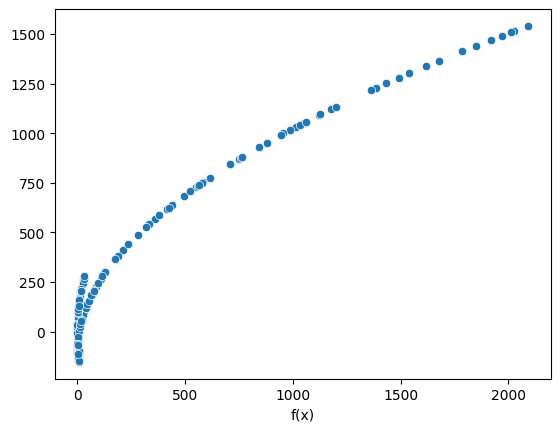

In [35]:
sns.scatterplot(x=y_test,y=y_pred)

<Axes: xlabel='f(x)'>

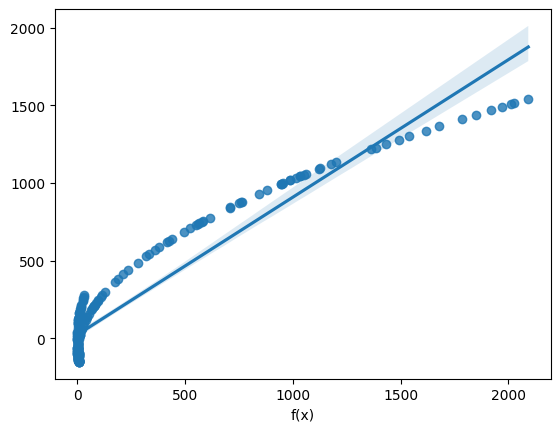

In [38]:
sns.regplot(x=y_test,y=y_pred)

In [39]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

124.12510160311675
23639.28556992524
0.9082594989538533
